# Customer Churn Exploratory Data Analysis

## Data Understanding and Overall Churn Analysis

This notebook performs the initial exploratory data analysis of the preprocessed customer churn dataset. It examines dataset structure, data quality, descriptive statistics, overall churn distribution, and selected customer characteristics.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df = pd.read_csv("customer_churn_preprocessed.csv")

df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Online Security,Online Backup,Device Protection,...,Payment Method,Total Frequency,Monthly Charges,Total Charges,Churn Value,CLTV,Internet Service_Fiber optic,Internet Service_No,Contract_One year,Contract_Two year
0,1,0,0,0,-1.236724,1,0,1,1,0,...,0,-0.176011,-0.362660,-0.958066,1,-0.959071,0,0,0,0
1,0,0,0,1,-1.236724,1,0,0,0,0,...,0,-1.145997,0.197365,-0.938874,1,-0.944189,1,0,0,0
2,0,0,0,1,-0.992402,1,1,0,0,1,...,0,0.793976,1.159546,-0.643789,1,-0.654598,1,0,0,0
3,0,0,1,1,-0.177995,1,1,0,0,1,...,0,1.278969,1.330711,0.338085,1,0.289158,1,0,0,0
4,1,0,0,1,0.677133,1,1,0,1,1,...,1,1.278969,1.294151,1.216150,1,1.237197,1,0,0,0


In [3]:
print("Number of customers:", df.shape[0])
print("Number of variables:", df.shape[1])

Number of customers: 7043
Number of variables: 24


### Observation

The dataset contains 7,043 customer records and 24 variables. Each row represents a customer, while the columns contain demographic, service, spending, contract, and churn-related information.

In [8]:
df.columns.tolist()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Paperless Billing',
 'Payment Method',
 'Total Frequency',
 'Monthly Charges',
 'Total Charges',
 'Churn Value',
 'CLTV',
 'Internet Service_Fiber optic',
 'Internet Service_No',
 'Contract_One year',
 'Contract_Two year']

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Gender                        7043 non-null   int64  
 1   Senior Citizen                7043 non-null   int64  
 2   Partner                       7043 non-null   int64  
 3   Dependents                    7043 non-null   int64  
 4   Tenure Months                 7043 non-null   float64
 5   Phone Service                 7043 non-null   int64  
 6   Multiple Lines                7043 non-null   int64  
 7   Online Security               7043 non-null   int64  
 8   Online Backup                 7043 non-null   int64  
 9   Device Protection             7043 non-null   int64  
 10  Tech Support                  7043 non-null   int64  
 11  Streaming TV                  7043 non-null   int64  
 12  Streaming Movies              7043 non-null   int64  
 13  Paperless Bill

### Observation

The dataset has already been preprocessed. Most categorical variables are numerically encoded, while continuous variables such as tenure and charges have also been transformed for analysis.

In [10]:
missing_values = df.isnull().sum()

missing_values

Gender                          0
Senior Citizen                  0
Partner                         0
Dependents                      0
Tenure Months                   0
Phone Service                   0
Multiple Lines                  0
Online Security                 0
Online Backup                   0
Device Protection               0
Tech Support                    0
Streaming TV                    0
Streaming Movies                0
Paperless Billing               0
Payment Method                  0
Total Frequency                 0
Monthly Charges                 0
Total Charges                   0
Churn Value                     0
CLTV                            0
Internet Service_Fiber optic    0
Internet Service_No             0
Contract_One year               0
Contract_Two year               0
dtype: int64

In [11]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


### Missing Value Analysis

No missing values were identified in the preprocessed dataset. Therefore, no additional missing-value treatment is required for this EDA stage.

In [12]:
duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 26


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Gender,7043.0,5.047565e-01,0.500013,0.000000,0.000000,1.000000,1.000000,1.000000
Senior Citizen,7043.0,1.621468e-01,0.368612,0.000000,0.000000,0.000000,0.000000,1.000000
Partner,7043.0,4.830328e-01,0.499748,0.000000,0.000000,0.000000,1.000000,1.000000
Dependents,7043.0,2.310095e-01,0.421508,0.000000,0.000000,0.000000,0.000000,1.000000
Tenure Months,7043.0,-4.842546e-17,1.000071,-1.318165,-0.951682,-0.137274,0.921455,1.613701
Phone Service,7043.0,9.031663e-01,0.295752,0.000000,1.000000,1.000000,1.000000,1.000000
Multiple Lines,7043.0,4.218373e-01,0.493888,0.000000,0.000000,0.000000,1.000000,1.000000
Online Security,7043.0,2.866676e-01,0.452237,0.000000,0.000000,0.000000,1.000000,1.000000
Online Backup,7043.0,3.448814e-01,0.475363,0.000000,0.000000,0.000000,1.000000,1.000000
Device Protection,7043.0,3.438875e-01,0.475038,0.000000,0.000000,0.000000,1.000000,1.000000


In [14]:
numerical_summary = df[
    [
        "Tenure Months",
        "Monthly Charges",
        "Total Charges",
        "CLTV"
    ]
].describe().T

numerical_summary

,count,mean,std,min,25%,50%,75%,max
Tenure Months,7043.0,-4.842546e-17,1.000071,-1.318165,-0.951682,-0.137274,0.921455,1.613701
Monthly Charges,7043.0,-6.456728e-17,1.000071,-1.545860,-0.972540,0.185733,0.833833,1.794352
Total Charges,7043.0,-4.842546e-17,1.000071,-1.005780,-0.829946,-0.390528,0.664803,2.825806
CLTV,7043.0,4.842546e-17,1.000071,-1.006629,-0.832645,-0.391236,0.665256,2.768924


### Descriptive Statistics

The main numerical variables have already been transformed during preprocessing. Therefore, their values represent standardized measurements rather than the original monetary or tenure values. These statistics are useful for understanding relative variation but should not be interpreted directly as original currency or month values.

In [15]:
churn_counts = df["Churn Value"].value_counts().sort_index()

churn_counts

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [16]:
print("Retained customers:", churn_counts.get(0, 0))
print("Churned customers:", churn_counts.get(1, 0))

Retained customers: 5174
Churned customers: 1869


In [17]:
churn_percentages = df["Churn Value"].value_counts(normalize=True).sort_index() * 100

churn_percentages

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

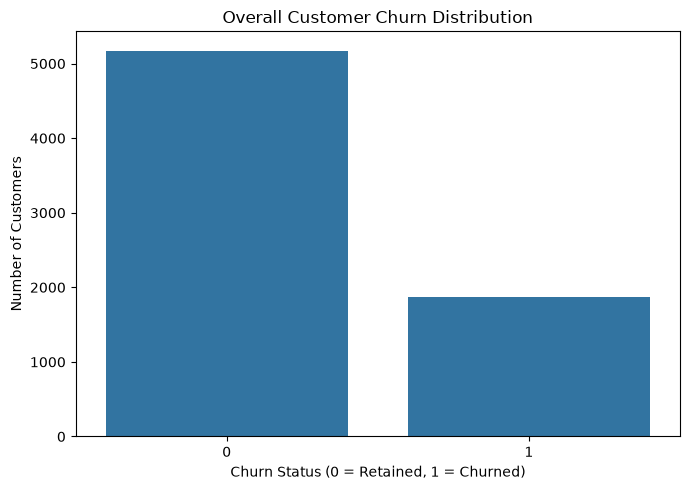

In [5]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="Churn Value")

plt.title("Overall Customer Churn Distribution")
plt.xlabel("Churn Status (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save figure
plt.savefig(
    "Figures/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Interpretation

The majority of customers are retained, while a smaller proportion have churned. The churn proportion represents the customer group that requires further investigation to identify common characteristics and possible retention opportunities.

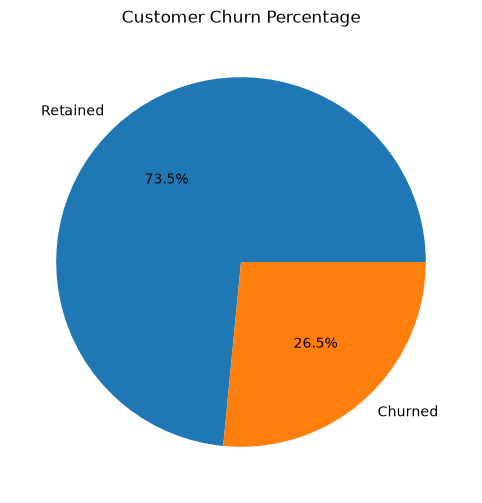

In [6]:
labels = ["Retained", "Churned"]

df["Churn Value"].value_counts().sort_index().plot(
    kind="pie",
    labels=labels,
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Customer Churn Percentage")
plt.ylabel("")

plt.savefig(
    "Figures/churn_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
gender_churn = pd.crosstab(
    df["Gender"],
    df["Churn Value"],
    normalize="index"
) * 100

gender_churn

Churn Value,0,1
Gender,,
0,73.079128,26.920872
1,73.839662,26.160338


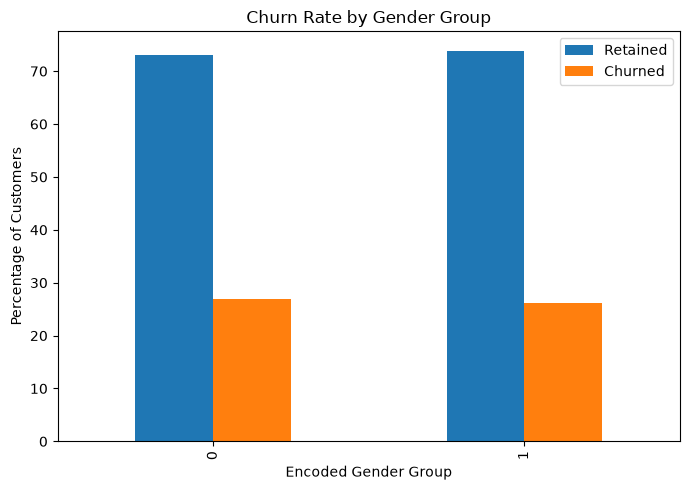

In [11]:
gender_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Gender Group")
plt.xlabel("Encoded Gender Group")
plt.ylabel("Percentage of Customers")
plt.legend(["Retained", "Churned"])

plt.tight_layout()
plt.show()




### Gender Insight

The churn percentages of the two encoded gender groups can be compared to determine whether gender appears to have a meaningful association with churn. The original preprocessing mapping should be referenced before assigning Male/Female labels to values 0 and 1.

In [23]:
senior_churn = pd.crosstab(
    df["Senior Citizen"],
    df["Churn Value"],
    normalize="index"
) * 100

senior_churn

Churn Value,0,1
Senior Citizen,,
0,76.393832,23.606168
1,58.318739,41.681261


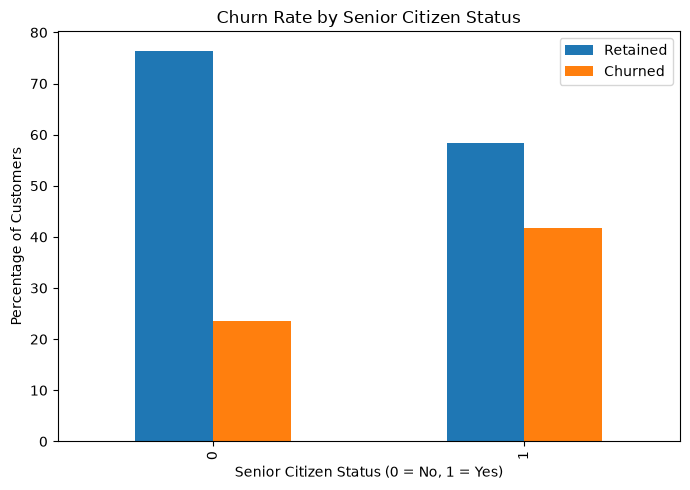

In [24]:
senior_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen Status (0 = No, 1 = Yes)")
plt.ylabel("Percentage of Customers")
plt.legend(["Retained", "Churned"])

plt.tight_layout()
plt.show()

### Senior Citizen Insight

The analysis compares churn rates between senior and non-senior customers. A higher churn percentage in one group would indicate that the group may require more targeted retention strategies.

In [25]:
partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn Value"],
    normalize="index"
) * 100

partner_churn

Churn Value,0,1
Partner,,
0,67.042021,32.957979
1,80.335097,19.664903


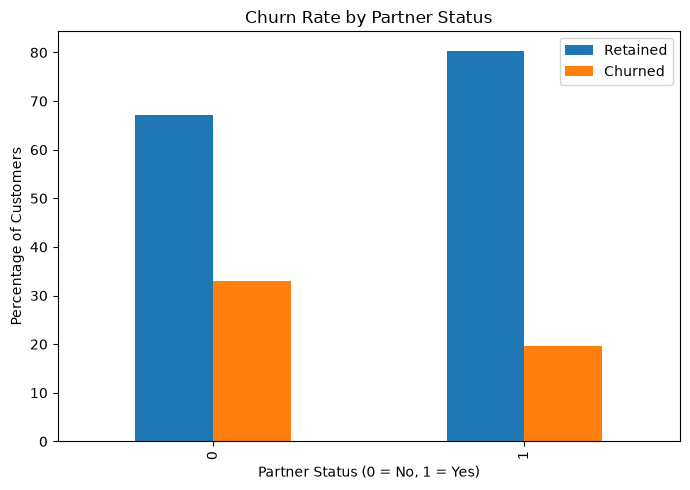

In [26]:
partner_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner Status (0 = No, 1 = Yes)")
plt.ylabel("Percentage of Customers")
plt.legend(["Retained", "Churned"])

plt.tight_layout()
plt.show()

In [27]:
dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn Value"],
    normalize="index"
) * 100

dependents_churn

Churn Value,0,1
Dependents,,
0,67.448301,32.551699
1,93.484942,6.515058


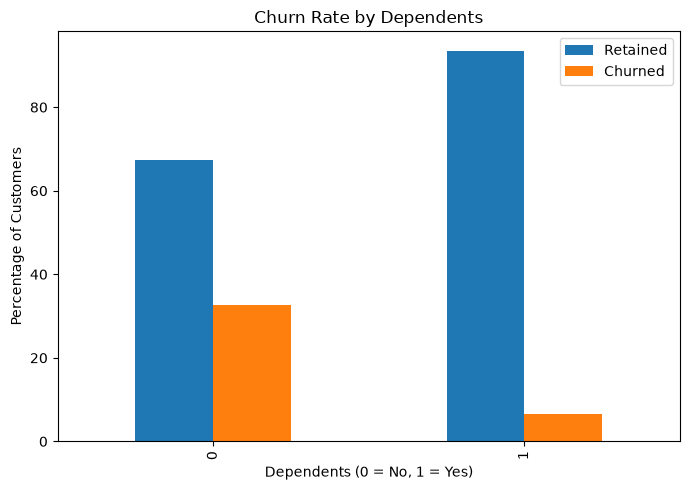

In [28]:
dependents_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents (0 = No, 1 = Yes)")
plt.ylabel("Percentage of Customers")
plt.legend(["Retained", "Churned"])

plt.tight_layout()
plt.show()

In [29]:
demographic_variables = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents"
]

for variable in demographic_variables:
    print(f"\nChurn rate by {variable}")
    
    result = (
        df.groupby(variable)["Churn Value"]
        .agg(["count", "mean"])
        .rename(columns={"count": "Customers", "mean": "Churn Rate"})
    )
    
    result["Churn Rate"] = result["Churn Rate"] * 100
    
    display(result)


Churn rate by Gender


,Customers,Churn Rate
Gender,,
0,3488,26.920872
1,3555,26.160338



Churn rate by Senior Citizen


,Customers,Churn Rate
Senior Citizen,,
0,5901,23.606168
1,1142,41.681261



Churn rate by Partner


,Customers,Churn Rate
Partner,,
0,3641,32.957979
1,3402,19.664903



Churn rate by Dependents


,Customers,Churn Rate
Dependents,,
0,5416,32.551699
1,1627,6.515058


#  Key Findings

1. The dataset contains 7,043 customer records and 24 preprocessed variables.

2. Data quality checks were performed for missing values and duplicate records.

3. Overall customer churn was examined using customer counts and churn percentages.

4. Customer characteristics including gender group, senior citizen status, partner status, and dependent status were compared against churn.

5. The demographic analysis identifies groups with relatively higher churn percentages, which can be investigated further together with tenure, contract, payment, and service factors in the next stages of the EDA.

## Business Meaning

The initial analysis provides a customer-level view of churn and helps identify demographic groups that may require greater attention. These findings should be combined with Member 2's behavioural and service analysis and Member 3's advanced business analysis before making final retention recommendations.

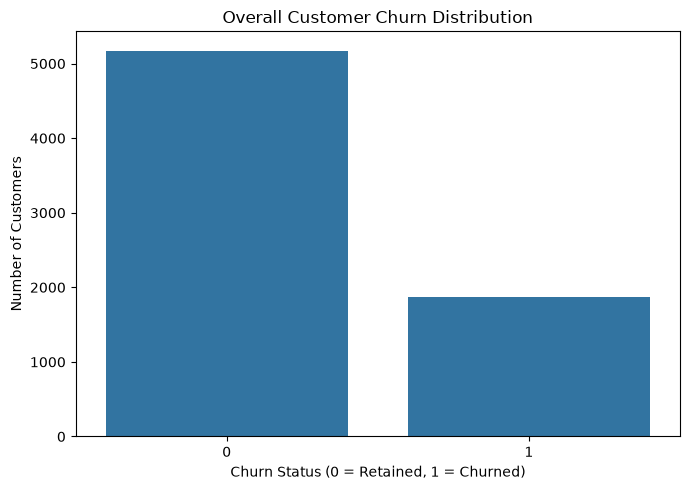

In [30]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Churn Value")

plt.title("Overall Customer Churn Distribution")
plt.xlabel("Churn Status (0 = Retained, 1 = Churned)")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.savefig(
    "../visualizations/churn_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()